# Exploratory Data Analysis (EDA) & Model Training
The dataset we are using comes from two main logs (Touch and Sensor). Because the *Machine Learning* model requires each observation row (swiping/sensor record) to predict its profile (`Mindful` or `Mindless`), we will perform:
1. **Merge AsOf**: Merge each Touch history with the nearest Sensor record based on *Timestamp*.
2. **EDA**: Analysis of variable distributions.
3. **Preprocessing**: Handling Missing Values, Encoding, Scaling.
4. **Training**: *Random Forest*, *XGBoost*, and *SVM*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load Master Data
touch_df = pd.read_csv('master/Master_TouchLog_All.csv')
sensor_df = pd.read_csv('master/Master_SensorLog_All.csv')

# Keep accelerometer rows only: GYRO magnitude is angular velocity in rad/s (~0.001),
# not m/s^2, so mixing sensor types corrupts Magnitude and gives NaN Pitch/Roll
# whenever a gyro row happens to be the nearest match in the merge below.
sensor_df = sensor_df[sensor_df['Sensor_Type'] == 'ACCEL']

# Clean and sort by Timestamp for accurate merging
touch_df = touch_df.dropna(subset=['Timestamp']).sort_values('Timestamp')
sensor_df = sensor_df.dropna(subset=['Timestamp']).sort_values('Timestamp')

# Ensure Timestamp is integer type
touch_df['Timestamp'] = touch_df['Timestamp'].astype(np.int64)
sensor_df['Timestamp'] = sensor_df['Timestamp'].astype(np.int64)

# Merge data based on nearest timestamp with a tolerance of 1000 milliseconds (1 second)
df_merged = pd.merge_asof(
    touch_df, 
    sensor_df[['Timestamp', 'Magnitude', 'Pitch', 'Roll', 'Participant_ID', 'Condition']], 
    on='Timestamp', 
    by=['Participant_ID', 'Condition'],
    direction='nearest',
    tolerance=1000
)

print(f"Total rows after merging: {len(df_merged)}")
df_merged.head()

c:\Users\leona\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\leona\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Total rows after merging: 15884


,Timestamp,Event_Type,ScrollDeltaX,ScrollDeltaY,PackageName,Time_Delta_Sec,Swipe_Distance,Scroll_Velocity,Participant_ID,Condition,Magnitude,Pitch,Roll
0,1777454311634,SCROLL,168,0,com.ss.android.ugc.trill,NaN,168.0,NaN,P-001,Mindful,9.988351,-0.150985,-2.272232
1,1777454313936,CLICK,0,0,com.ss.android.ugc.trill,2.302,0.0,0.0,P-001,Mindful,10.244940,26.381798,-1.030765
2,1777454314805,SCROLL,0,0,com.ss.android.ugc.trill,0.869,0.0,0.0,P-001,Mindful,9.872883,22.215202,-1.147563
3,1777454318885,SCROLL,0,0,com.ss.android.ugc.trill,4.080,0.0,0.0,P-001,Mindful,9.238677,21.610739,-7.362593
4,1777454319319,SCROLL,0,0,com.ss.android.ugc.trill,0.434,0.0,0.0,P-001,Mindful,10.393905,24.473361,-4.649908


---
### EDA (Exploratory Data Analysis)

Violin plot excludes 107 rows with gaps > 15 s (idle pauses)


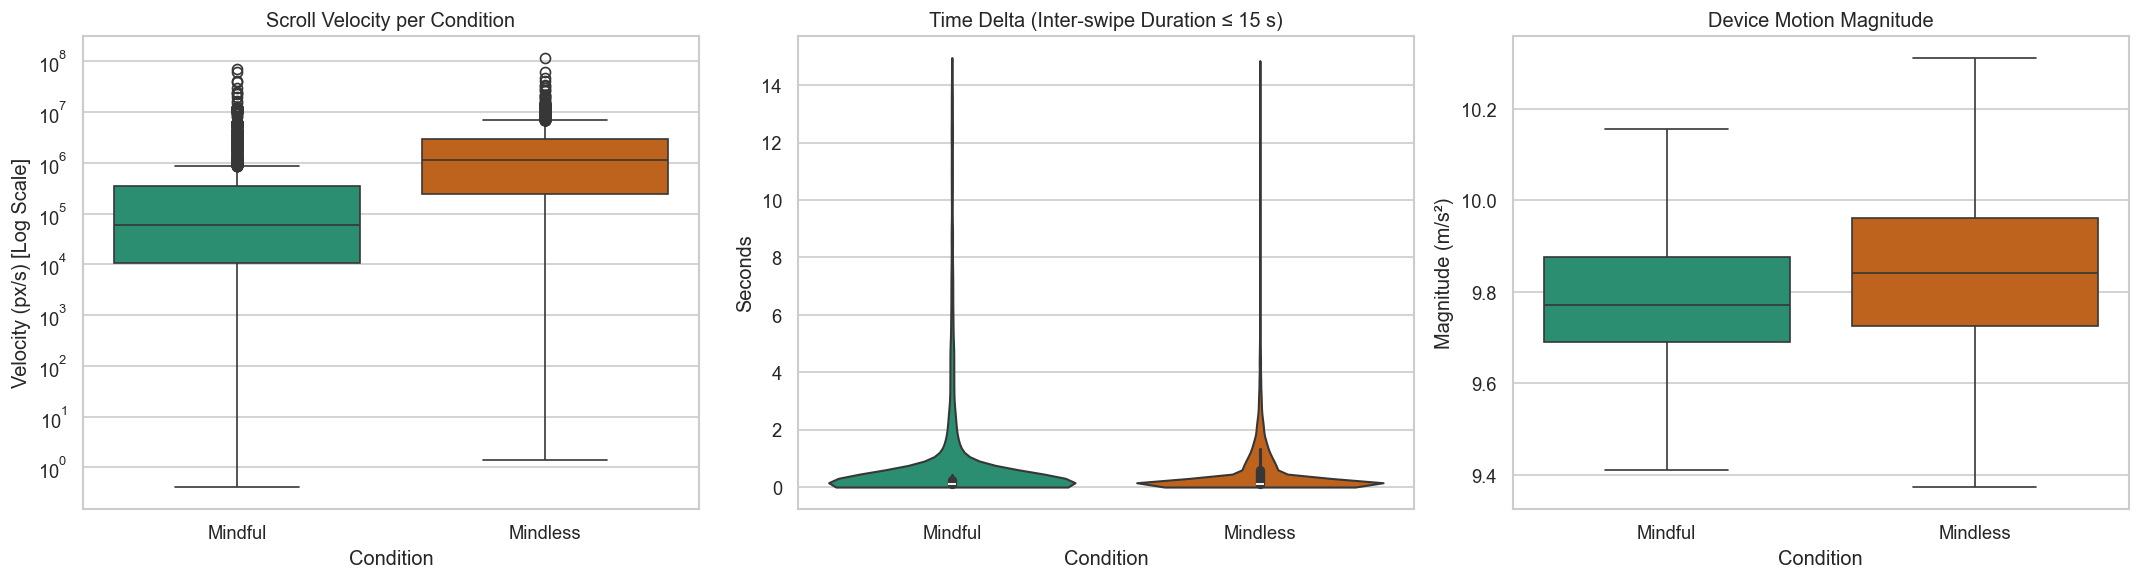

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

# Fixed color per condition (colorblind-safe pair), reused by every plot below
PALETTE = {'Mindful': '#1b9e77', 'Mindless': '#d95f02'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scroll Velocity (log scale requires strictly positive values,
# zeros are CLICK events / zero-distance scrolls, not real velocities)
vel = df_merged[df_merged['Scroll_Velocity'] > 0]
sns.boxplot(data=vel, x='Condition', y='Scroll_Velocity', hue='Condition',
            palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Scroll Velocity per Condition')
axes[0].set_ylabel('Velocity (px/s) [Log Scale]')

# Plot 2: Inter-swipe Duration
# Filter the data instead of clipping with ylim: the KDE must be estimated only on
# the plotted range, otherwise long idle gaps (minutes) inflate the bandwidth and
# the violin degenerates into a solid block. cut=0 stops the KDE at the data
# bounds so the violin cannot extend below 0 seconds.
td = df_merged[df_merged['Time_Delta_Sec'].between(0, 15)]
excluded = df_merged['Time_Delta_Sec'].notna().sum() - len(td)
print(f"Violin plot excludes {excluded} rows with gaps > 15 s (idle pauses)")
sns.violinplot(data=td, x='Condition', y='Time_Delta_Sec', hue='Condition',
               palette=PALETTE, legend=False, cut=0, ax=axes[1])
axes[1].set_title('Time Delta (Inter-swipe Duration ≤ 15 s)')
axes[1].set_ylabel('Seconds')

# Plot 3: Device Physical Magnitude (accelerometer only, clusters around gravity 9.8)
sns.boxplot(data=df_merged, x='Condition', y='Magnitude', hue='Condition',
            palette=PALETTE, legend=False, showfliers=False, ax=axes[2])
axes[2].set_title('Device Motion Magnitude')
axes[2].set_ylabel('Magnitude (m/s²)')

plt.tight_layout()
plt.show()

#### Class Balance & Activity per Participant
How much data each condition and each participant contributes, plus the interaction-type mix (`SCROLL` vs `CLICK`) per condition.

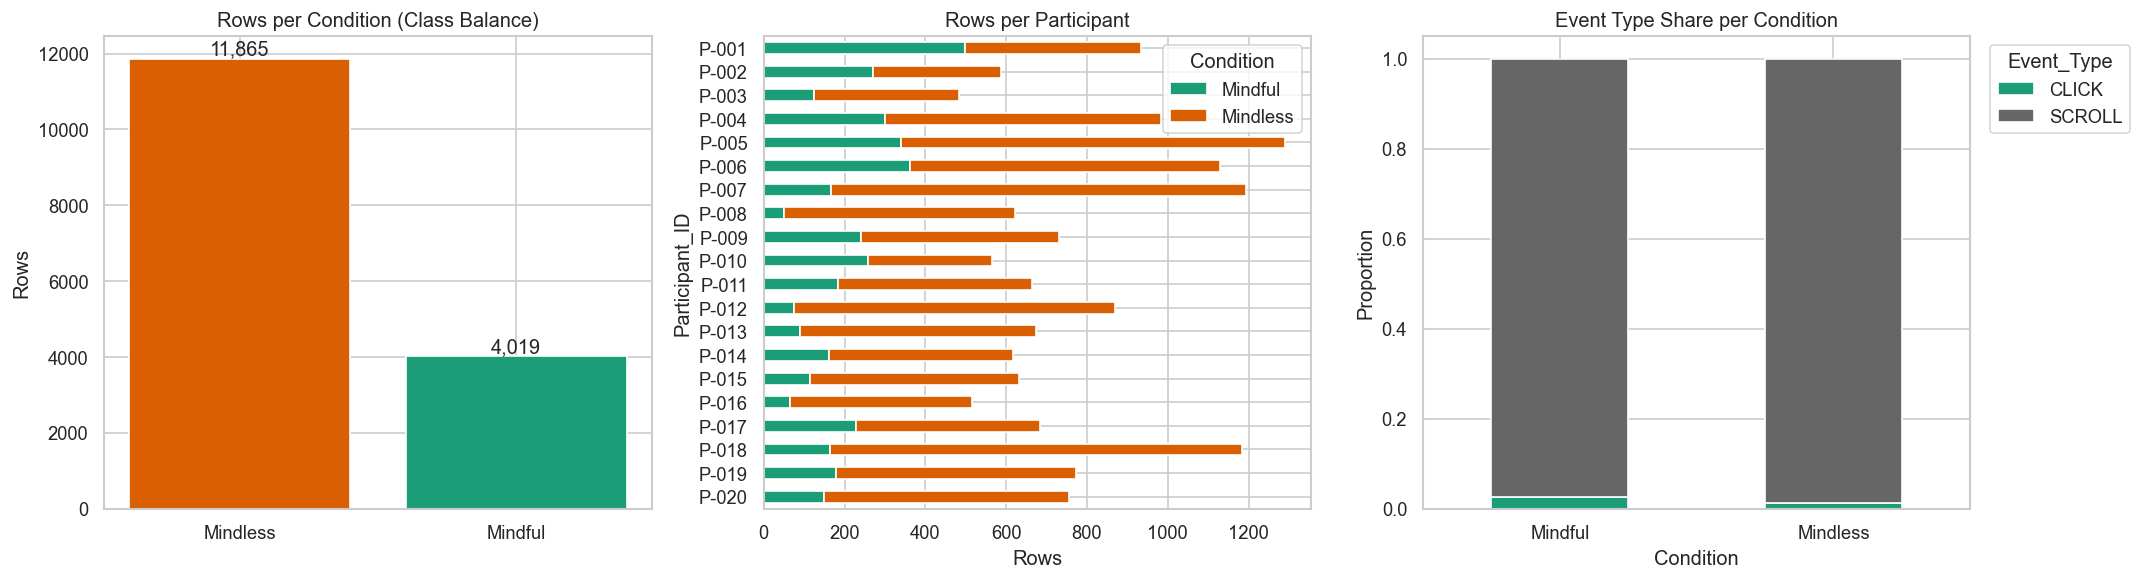

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class balance
counts = df_merged['Condition'].value_counts()
axes[0].bar(counts.index, counts.values, color=[PALETTE[c] for c in counts.index])
axes[0].set_title('Rows per Condition (Class Balance)')
axes[0].set_ylabel('Rows')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# Rows per participant per condition — shows who dominates the dataset,
# which matters because the train/test split is grouped by participant
part_counts = df_merged.groupby(['Participant_ID', 'Condition']).size().unstack(fill_value=0)
part_counts.plot(kind='barh', stacked=True, color=PALETTE, ax=axes[1])
axes[1].set_title('Rows per Participant')
axes[1].set_xlabel('Rows')
axes[1].invert_yaxis()

# Event type share within each condition
event_share = pd.crosstab(df_merged['Condition'], df_merged['Event_Type'], normalize='index')
event_share.plot(kind='bar', stacked=True, colormap='Dark2', ax=axes[2], rot=0)
axes[2].set_title('Event Type Share per Condition')
axes[2].set_ylabel('Proportion')
axes[2].legend(title='Event_Type', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### Feature Distributions
Per-class density (`common_norm=False`) so the smaller *Mindful* class is not visually flattened by the class imbalance. Heavy-tailed touch features use a log x-axis; zero values (e.g. `CLICK` events) are excluded on log axes.

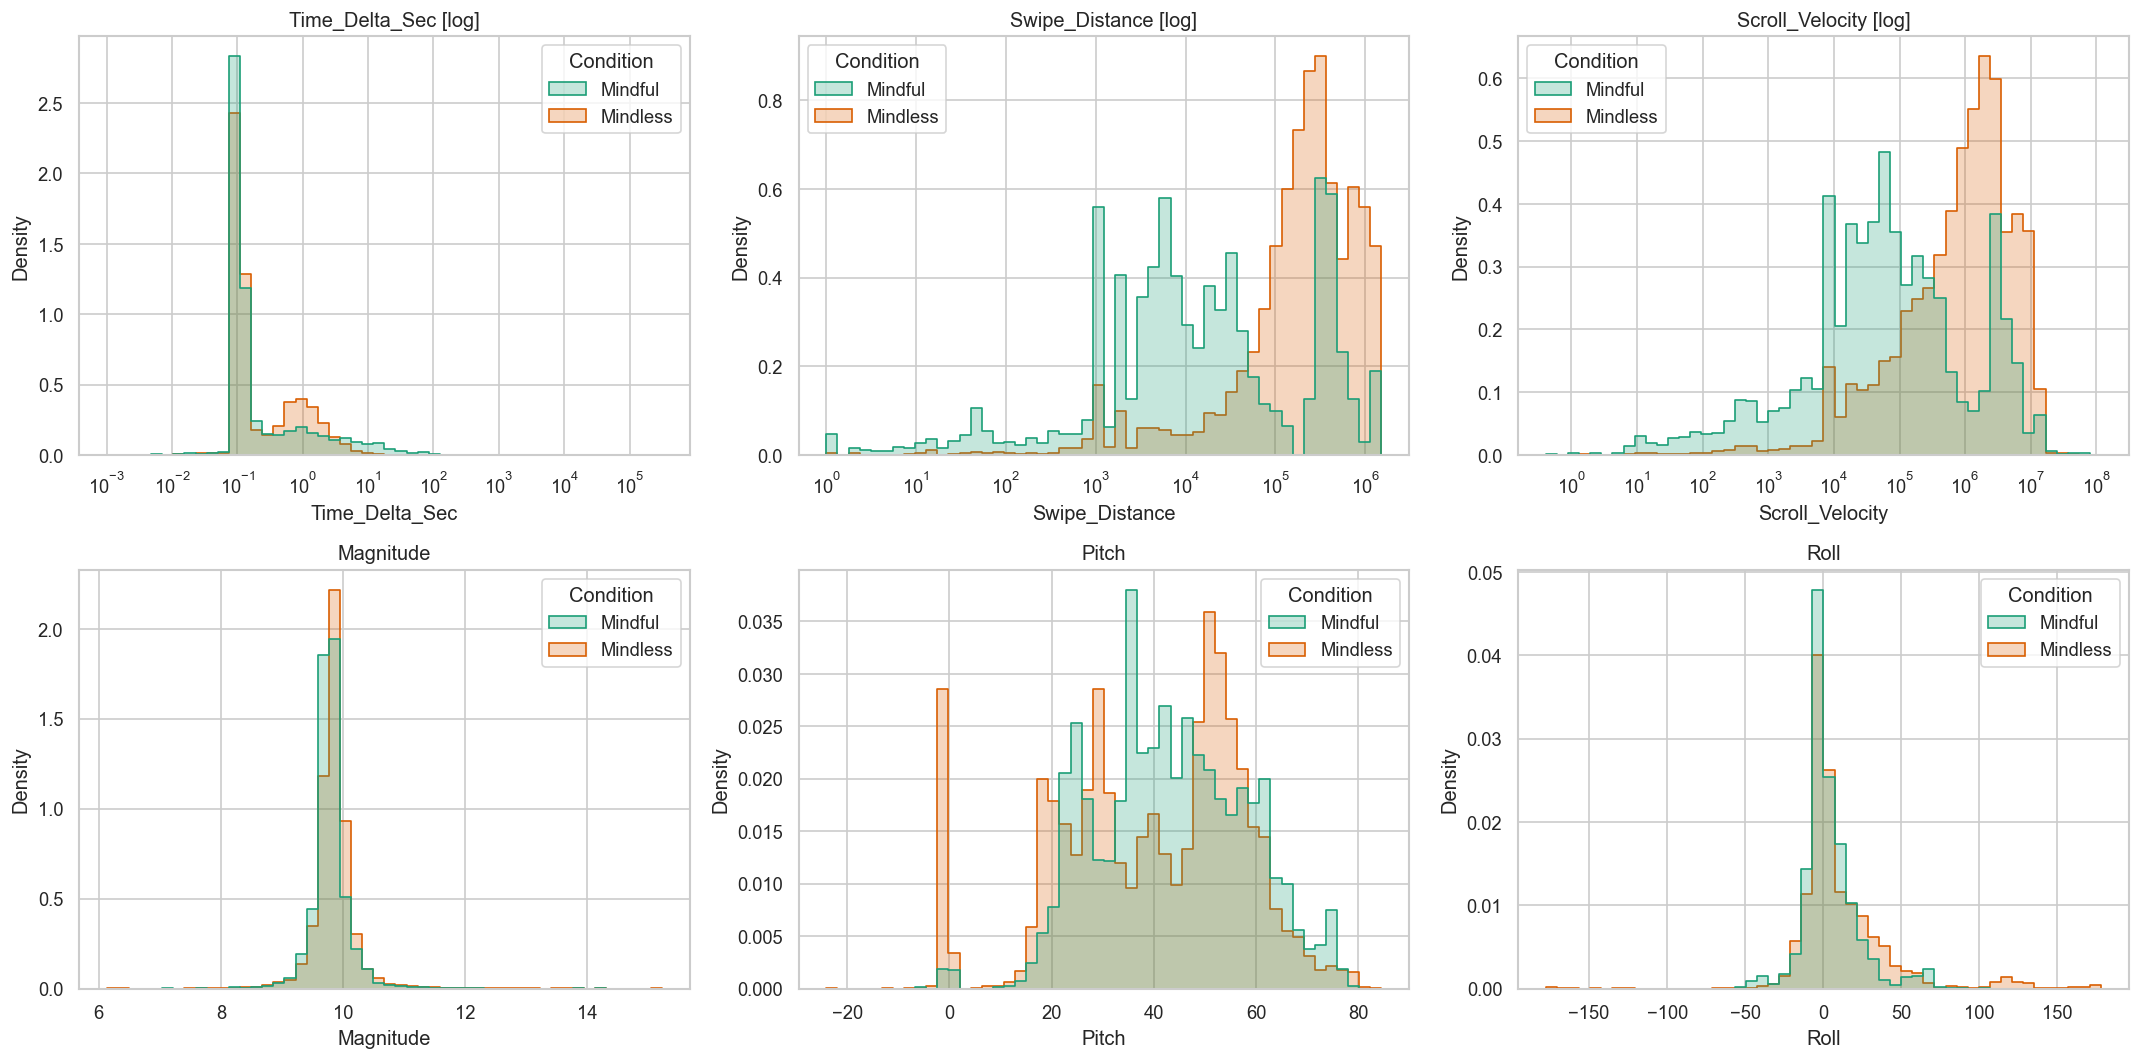

In [4]:
num_features = ['Time_Delta_Sec', 'Swipe_Distance', 'Scroll_Velocity', 'Magnitude', 'Pitch', 'Roll']
log_features = {'Time_Delta_Sec', 'Swipe_Distance', 'Scroll_Velocity'}  # heavy right tails

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flat, num_features):
    use_log = col in log_features
    # log axis needs strictly positive values
    data = df_merged[df_merged[col] > 0] if use_log else df_merged
    sns.histplot(data=data, x=col, hue='Condition', palette=PALETTE, ax=ax,
                 log_scale=use_log, stat='density', common_norm=False,
                 element='step', bins=50)
    ax.set_title(f'{col}{" [log]" if use_log else ""}')

plt.tight_layout()
plt.show()

#### Correlation Matrix
Spearman correlation between the model features. Note that `Scroll_Velocity` is derived from `Swipe_Distance / Time_Delta_Sec`, so a strong correlation with those two columns is expected by construction, not an empirical finding.

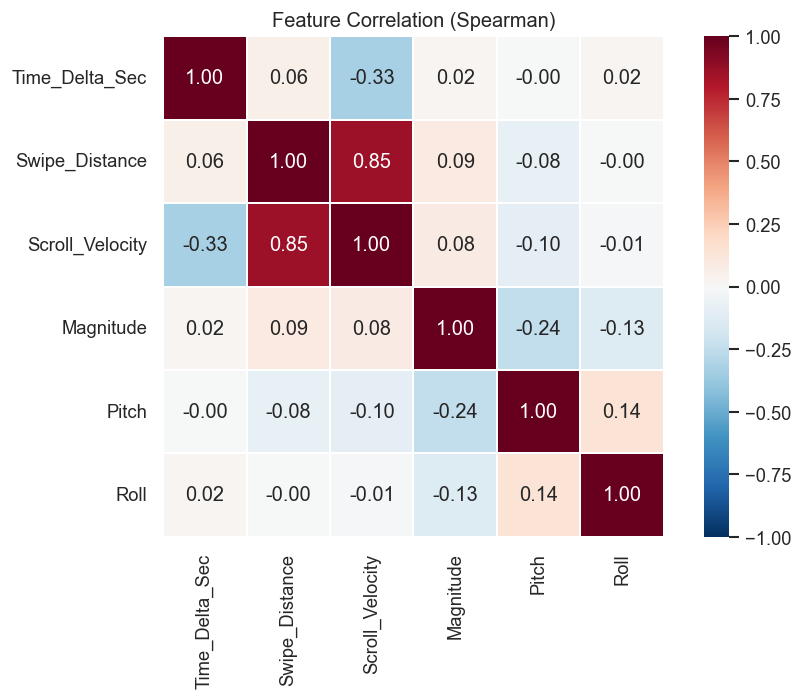

In [5]:
# Spearman rank correlation: robust to the heavy right tails of the touch features
num_features = ['Time_Delta_Sec', 'Swipe_Distance', 'Scroll_Velocity', 'Magnitude', 'Pitch', 'Roll']
corr = df_merged[num_features].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=1, linecolor='white')
plt.title('Feature Correlation (Spearman)')
plt.tight_layout()
plt.show()

---
### Data Preprocessing
Removing Nulls from numerical features, performing Encoding on the Label (`Condition`), and Feature Standardization before feeding into the *Machine Learning Model*.

In [6]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Feature columns
feature_cols = ['Time_Delta_Sec', 'Swipe_Distance', 'Scroll_Velocity', 'Magnitude', 'Pitch', 'Roll']

# Clean Data
df_model = df_merged.copy()
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model = df_model.dropna(subset=feature_cols)

X = df_model[feature_cols]

# Target Label (Mindful = 0, Mindless = 1)
le = LabelEncoder()
y = le.fit_transform(df_model['Condition'])

# Extract Label Info
print("Original vs Encoded Label Mapping:")
for class_map in zip(le.classes_, le.transform(le.classes_)):
    print(class_map)

# Prevent Data Leakage by grouping Participants
groups = df_model['Participant_ID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Save Participant IDs so we know who is in the test set
    test_groups = groups.iloc[test_idx].unique()

print(f"Training data: {X_train.shape[0]}")
print(f"Testing data: {X_test.shape[0]}")
print(f"Participants exclusively used for TESTING: {test_groups}")

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Original vs Encoded Label Mapping:
('Mindful', 0)
('Mindless', 1)
Training data: 12628
Testing data: 3210
Participants exclusively used for TESTING: <ArrowStringArray>
['P-001', 'P-002', 'P-016', 'P-018']
Length: 4, dtype: str


---
### Model Training & Evaluation

In [7]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, f1_score
import pandas as pd

# Calculate scale_pos_weight for XGBoost (Ratio of negative to positive class)
# Mindful=0, Mindless=1. Mindless is majority, so this scales down class 1 weights.
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
spw = neg_class_count / pos_class_count

# Initialize Models with class weights
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, random_state=42, eval_metric='logloss', scale_pos_weight=spw),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, random_state=42, class_weight='balanced')
}

results = []

print("=== Model Training Process ===")
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    # Using 'macro' average F1 is fairer for evaluating models on imbalanced datasets 
    f1 = f1_score(y_test, y_pred, average='macro')
    
    print(f"Classification Report for {name}:")
    print(classification_report(y_test, y_pred, digits=6))
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1-Score (Macro)': f1
    })

# Show Evaluation Summary
results_df = pd.DataFrame(results).sort_values(by='F1-Score (Macro)', ascending=False)
display(results_df)

=== Model Training Process ===

Training Random Forest...
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0   0.702390  0.920202  0.796677       990
           1   0.958704  0.826126  0.887491      2220

    accuracy                       0.855140      3210
   macro avg   0.830547  0.873164  0.842084      3210
weighted avg   0.879654  0.855140  0.859483      3210


Training XGBoost...
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0   0.621145  0.854545  0.719388       990
           1   0.922078  0.767568  0.837758      2220

    accuracy                       0.794393      3210
   macro avg   0.771612  0.811057  0.778573      3210
weighted avg   0.829267  0.794393  0.801251      3210


Training SVM (RBF)...
Classification Report for SVM (RBF):
              precision    recall  f1-score   support

           0   0.479101  0.926263  0.631543       990
           1   0.94367

,Model,Accuracy,F1-Score (Macro)
0,Random Forest,0.855140,0.842084
1,XGBoost,0.794393,0.778573
2,SVM (RBF),0.666667,0.663610
